### FIN 294 Assignment 2

**Authors:** Darius, Ryota (Rio) Yokoyama (ry4757), Zac

---

**Research Question:**  
Do firms with higher R&D investment earn higher risk-adjusted returns?

**Approach:**  
1. Sort firms annually into portfolios based on their **weighted R&D capital** (XRDW) scaled by lagged market cap  
2. Portfolio 0 = firms with **zero reported R&D**; Portfolios 1–5 = quintiles of positive XRDW/ME  
3. Compute **equal-weighted (EW)** and **value-weighted (VW)** portfolio returns each month  
4. Estimate **CAPM** and **Fama-French 3-Factor** alphas to measure risk-adjusted performance  
5. Analyze results over the full sample (1980–2022) and two sub-periods (pre/post 2000)

**Key Design Choices:**  
- 6-month reporting lag: fiscal year t data is not used until 6 months after fiscal year end  
- XRDW = XRD(t) + 0.8·XRD(t-1) + 0.6·XRD(t-2) + 0.4·XRD(t-3) + 0.2·XRD(t-4) (Lev & Sougiannis 1996)  
- Exclude financials (SIC 6000–6999), pharma (SIC 2834), firms below inflation-adjusted $100M market cap (2022 base), and the top 100 firms by market cap

---
## Step 1: Setup — Imports, Constants, and Database Connection

In [200]:
# Standard data manipulation and analysis libraries
import pandas as pd
import numpy as np
import datetime as dt
import wrds                            # Wharton Research Data Services API
import matplotlib.pyplot as plt
from dateutil.relativedelta import *   # Relative date arithmetic (e.g., months=60)
from pandas.tseries.offsets import *   # MonthEnd offset for aligning dates
from scipy import stats
from tqdm import tqdm                  # Progress bars for long-running loops
import warnings
warnings.filterwarnings('ignore')      # Suppress noisy pandas/numpy deprecation warnings

In [201]:
# Connect to WRDS (Wharton Research Data Services)
# Requires valid WRDS credentials; prompts for password on first run
db = wrds.Connection(wrds_username='zkg232')

Loading library list...
Done


In [202]:
# Main analysis window
START_DATE = dt.datetime(1980, 1, 1)
END_DATE   = dt.datetime(2022, 12, 31)

# Date used to split results into two sub-periods for comparison
SPLIT_DATE = dt.datetime(2000, 1, 1)

# Extended start date: pull raw data further back than START_DATE to avoid losing
# observations at the beginning of the sample due to:
#   (1) The 6-month reporting lag applied to Compustat data
#   (2) The 4-year lookback window needed to compute XRDW (weighted R&D capital)
# Going back 60 months (5 years) ensures all 1980 portfolio sorts have full XRDW history
START_EXT = START_DATE - relativedelta(months=60)

---
## Step 2: Load CRSP Monthly Stock Data

In [203]:
# Pull monthly stock file (crsp.msf) joined with name history (crsp.msenames)
# in a single SQL query to get returns, shares outstanding, price, and exchange info.
#
# Filters applied in SQL for efficiency:
#   - shrcd IN (10, 11): ordinary common shares (excludes ADRs, closed-end funds, REITs, etc.)
#   - exchcd IN (1, 2, 3): NYSE, AMEX, NASDAQ only
#   - Date range includes extended start to support XRDW lags
sql_query = f"""
    SELECT 
        a.permno, a.permco, a.date, 
        a.ret, a.shrout, a.prc, a.hsiccd,
        b.namedt, b.nameendt, b.shrcd, b.exchcd, b.siccd
    FROM crsp.msf AS a
    INNER JOIN crsp.msenames AS b
    ON a.permno = b.permno
    AND a.date >= b.namedt 
    AND a.date <= b.nameendt
    WHERE a.date BETWEEN '{START_EXT.strftime('%Y-%m-%d')}' AND '{END_DATE.strftime('%Y-%m-%d')}'
    AND b.shrcd IN (10, 11)
    AND b.exchcd IN (1, 2, 3)
    """

print("Executing combined SQL query...")
crsp_merged = db.raw_sql(sql_query)

Executing combined SQL query...


In [204]:
# Convert date columns to datetime and enforce numeric types.
# CRSP sometimes stores returns as strings (e.g., 'C', 'B') for corporate actions —
# coerce these to NaN so they don't corrupt calculations.
crsp_merged['date'] = pd.to_datetime(crsp_merged['date'])
crsp_merged['namedt'] = pd.to_datetime(crsp_merged['namedt'])
crsp_merged['nameendt'] = pd.to_datetime(crsp_merged['nameendt'])

crsp_merged['ret'] = pd.to_numeric(crsp_merged['ret'], errors='coerce')

crsp_merged = crsp_merged.astype({
    'permno': 'int64',
    'permco': 'int64',
    'hsiccd': 'float64',
    'prc':    'float64',
    'ret':    'float64',
    'shrout': 'float64',
    'shrcd':  'int64',
    'exchcd': 'int64',
    'siccd':  'int64'
})

print(f"Data loaded and merged. Shape: {crsp_merged.shape}")
display(crsp_merged[['permno', 'date', 'shrcd', 'exchcd']].head())

Data loaded and merged. Shape: (2939092, 12)


,permno,date,shrcd,exchcd
0,10000,1986-01-31,10,3
1,10000,1986-02-28,10,3
2,10000,1986-03-31,10,3
3,10000,1986-04-30,10,3
4,10000,1986-05-30,10,3


In [205]:
# Load delisting returns from crsp.msedelist.
# When a stock is delisted, CRSP records a separate "delisting return" (dlret).
# Ignoring delisting returns introduces survivorship bias — delisted firms often
# had negative returns at delisting, so omitting them overstates portfolio performance.
dlret = db.raw_sql(f"""
    SELECT permno, dlret, dlstdt
    FROM crsp.msedelist
    WHERE dlstdt BETWEEN '{START_EXT.strftime('%Y-%m-%d')}' AND '{END_DATE.strftime('%Y-%m-%d')}'
""")
dlret['dlstdt'] = pd.to_datetime(dlret['dlstdt'])

dlret = dlret.astype({
    'permno': 'int64',
    'dlret':  'float64'
})

dlret.dtypes

permno             int64
dlret            float64
dlstdt    datetime64[ns]
dtype: object

In [206]:
# Align all dates to month-end so CRSP and delisting data merge correctly on the same key
crsp_merged[['permco', 'permno', 'shrcd', 'exchcd']] = crsp_merged[[
    'permco', 'permno', 'shrcd', 'exchcd']].astype(int)

crsp_merged['jdate'] = crsp_merged['date'] + MonthEnd(0)   # snap to end of month

dlret.permno = dlret.permno.astype(int)
dlret['jdate'] = dlret['dlstdt'] + MonthEnd(0)

# Left-join delisting returns onto the main CRSP data by (permno, month-end date).
# Most rows will have NaN dlret (stock was not delisted that month).
crsp = pd.merge(crsp_merged, dlret, how='left', on=['permno', 'jdate'])

# Compute delisting-adjusted return:
#   retadj = (1 + ret) * (1 + dlret) - 1
# If either is missing, treat it as 0 so the other component is preserved.
crsp['retadj'] = (1 + crsp['ret'].fillna(0)) * (1 + crsp['dlret'].fillna(0)) - 1

In [207]:
# Compute market equity (me) = |price| × shares outstanding × 1000
# Price in CRSP can be negative (bid-ask midpoint when no last trade exists), so take abs()
# shrout is in thousands of shares, so multiply by 1000 to get total shares
crsp['me'] = crsp['prc'].abs() * crsp['shrout'] * 1000

# Keep only the columns needed for downstream analysis
crsp = crsp[['permno', 'permco', 'siccd', 'jdate', 'prc', 'shrout', 'me', 'ret', 'retadj']]
crsp['jdate'] = pd.to_datetime(crsp['jdate'])
crsp.dtypes

permno             int64
permco             int64
siccd              int64
jdate     datetime64[ns]
prc              float64
shrout           float64
me               float64
ret              float64
retadj           float64
dtype: object

In [208]:
# Sort by security and date — required for correct forward-filling later
crsp = crsp.sort_values(by=['permno', 'jdate'])
crsp.head()

,permno,permco,siccd,jdate,prc,shrout,me,ret,retadj
0,10000,7952,3990,1986-01-31,-4.37500,3680.0,16100000.00,NaN,0.000000
1,10000,7952,3990,1986-02-28,-3.25000,3680.0,11960000.00,-0.257143,-0.257143
2,10000,7952,3990,1986-03-31,-4.43750,3680.0,16330000.00,0.365385,0.365385
3,10000,7952,3990,1986-04-30,-4.00000,3793.0,15172000.00,-0.098592,-0.098592
4,10000,7952,3990,1986-05-31,-3.10938,3793.0,11793878.34,-0.222656,-0.222656


In [209]:
# Sanity check: verify the date range and return bounds are as expected
print(crsp['jdate'].min(), crsp['jdate'].max())
print(crsp['retadj'].min(), crsp['retadj'].max())

1975-01-31 00:00:00 2022-12-31 00:00:00
-1.0 24.0


---
## Step 3: Load and Clean Compustat Annual Fundamentals

We need R&D expenditure (xrd) from Compustat to construct the XRDW signal.

**Pipeline:**
1. Pull `comp.funda` (annual fundamentals) — key variable is `xrd` (R&D expense)
2. Apply sample filters: US firms, USD currency, exclude financials and pharma
3. Compute XRDW = weighted R&D capital using a 4-year declining-weight depreciation schedule
4. Link to CRSP via the CCM crosswalk table (`crsp.ccmxpf_linktable`)
5. Apply a **6-month reporting lag** before merging into the monthly return data

In [210]:
# Pull Compustat annual fundamentals.
# We load the full table (no date filter in SQL) then filter in Python to avoid
# missing rows caused by Compustat's datadate not always falling in the calendar year.
# Key columns:
#   gvkey    = Compustat firm identifier
#   datadate = fiscal year end date
#   fyear    = fiscal year (used for lag merges)
#   xrd      = R&D expenditure (the core variable of interest)
#   sich     = historical SIC code (for industry exclusions)
#   exchg    = exchange code (to confirm listing on major exchanges)
#   curcd    = reporting currency
#   fic      = country of incorporation
comp = db.raw_sql(f"""
    SELECT gvkey, datadate, curcd, fic, sich, exchg, xrd, fyear, popsrc
    FROM comp.funda
""")

comp['datadate'] = pd.to_datetime(comp['datadate'])

# Filter to the extended date range
comp = comp.loc[
    (comp["datadate"] >= START_EXT) &
    (comp["datadate"] <= END_DATE)
]

comp = comp.astype({
    'gvkey':  'int64',
    'fyear':  'float64',
    'popsrc': 'str',
    'curcd':  'str',
    'xrd':    'float64',
    'exchg':  'float64',
    'fic':    'str',
    'sich':   'float64'
})

comp = comp.sort_values(['gvkey', 'datadate'])
comp.head()

,gvkey,datadate,curcd,fic,sich,exchg,xrd,fyear,popsrc
20,1000,1975-12-31,USD,USA,NaN,12.0,NaN,1975.0,D
21,1000,1975-12-31,USD,USA,NaN,12.0,NaN,1975.0,D
22,1000,1976-12-31,USD,USA,NaN,12.0,NaN,1976.0,D
23,1000,1976-12-31,USD,USA,NaN,12.0,NaN,1976.0,D
24,1000,1977-12-31,USD,USA,NaN,12.0,NaN,1977.0,D


### Compustat Sample Filters

Apply the following exclusions to the Compustat fundamentals data:
- **Population source = 'D'**: domestic (primary) Compustat population (excludes research files)
- **Currency = USD**: ensures financial data is comparable across firms
- **FIC = USA**: US-incorporated firms only
- **Exclude SIC 6000–6999**: financial firms (banks, insurance) — R&D is not meaningful for them
- **Exclude SIC 2834**: pharmaceutical preparations (often use a different R&D accounting treatment)
- **Exchange code 11–19**: listed on NYSE (11), AMEX (12), or NASDAQ (14) family of exchanges

In [211]:
# Filter 0: Keep only the domestic (primary) population source
comp = comp[comp['popsrc'] == 'D']

# Filter 1: Geographic and currency — US companies reporting in USD only
comp = comp[comp['curcd'] == 'USD']
comp = comp[comp['fic'] == 'USA']

# Filter 2: Industry exclusions based on historical SIC code (sich)
financials = (comp['sich'] >= 6000) & (comp['sich'] <= 6999)  # financial firms
pharma     = (comp['sich'] == 2834)                            # pharmaceutical preparations
comp = comp[~(financials | pharma)]

# Filter 3: Exchange restriction — keep only major US exchange listings (codes 11–19)
#   11 = NYSE, 12 = AMEX, 14 = NASDAQ; others in this range are valid exchange variants
comp = comp[(comp['exchg'] >= 11) & (comp['exchg'] <= 19)]

print(f"Final shape: {comp.shape}")

Final shape: (497107, 9)


In [212]:
# Keep only the columns needed downstream and sort for reproducibility
comp = comp[['gvkey', 'datadate', 'fyear', 'exchg', 'sich', 'fic', 'curcd', 'xrd']]
comp = comp.sort_values(by=['gvkey', 'datadate'])
comp.head()

,gvkey,datadate,fyear,exchg,sich,fic,curcd,xrd
20,1000,1975-12-31,1975.0,12.0,NaN,USA,USD,NaN
21,1000,1975-12-31,1975.0,12.0,NaN,USA,USD,NaN
22,1000,1976-12-31,1976.0,12.0,NaN,USA,USD,NaN
23,1000,1976-12-31,1976.0,12.0,NaN,USA,USD,NaN
24,1000,1977-12-31,1977.0,12.0,NaN,USA,USD,NaN


In [213]:
# Compute Weighted R&D Capital (XRDW) following Lev & Sougiannis (1996).
#
# XRDW captures the stock of R&D knowledge accumulated over prior years,
# with more recent spending weighted more heavily:
#   XRDW(t) = XRD(t) + 0.8*XRD(t-1) + 0.6*XRD(t-2) + 0.4*XRD(t-3) + 0.2*XRD(t-4)
#
# Implementation note: we merge on fyear (not datadate) to handle gaps in annual
# reporting correctly — if a firm skips a year, the fyear-based self-join will
# not accidentally carry forward stale data across the gap.

# De-duplicate so each (gvkey, fyear) has exactly one row; keep the row with
# the largest non-missing xrd value when duplicates exist
comp = comp.sort_values(
    ["gvkey", "fyear", "xrd"],
    ascending=[True, True, True],
    na_position='last'
).drop_duplicates(subset=["gvkey", "fyear"])

# Build lag columns by shifting fyear forward in a copy of the xrd series,
# then merging back. For example, lag 1: copy fyear → fyear+1 so that
# a firm's t-1 xrd aligns with its t row after the merge.
for lag in range(1, 5):
    lag_df = comp[["gvkey", "fyear", "xrd"]].copy()
    lag_df["fyear"] = lag_df["fyear"] + lag
    lag_df = lag_df.rename(columns={"xrd": f"xrd_lag{lag}"})
    comp = comp.merge(lag_df, on=["gvkey", "fyear"], how="left")

# Apply the declining weights; treat missing historical xrd as 0
# (consistent with treating no-R&D-spend years as contributing zero to XRDW)
comp["xrdw"] = (comp["xrd"].fillna(0)
               + 0.8 * comp["xrd_lag1"].fillna(0)
               + 0.6 * comp["xrd_lag2"].fillna(0)
               + 0.4 * comp["xrd_lag3"].fillna(0)
               + 0.2 * comp["xrd_lag4"].fillna(0))

# Drop intermediate lag columns — only xrdw is needed going forward
comp = comp.drop(columns=["xrd_lag1", "xrd_lag2", "xrd_lag3", "xrd_lag4"])

print(f"XRDW computed. Shape: {comp.shape}")
display(comp[["gvkey", "fyear", "xrd", "xrdw"]].dropna(subset=["xrd"]).head(10))

XRDW computed. Shape: (315080, 9)


,gvkey,fyear,xrd,xrdw
8,1001,1983.0,0.000,0.0000
10,1001,1985.0,0.000,0.0000
76,1008,1983.0,0.308,0.3080
77,1008,1984.0,0.398,0.6444
78,1008,1985.0,0.321,0.8242
106,1013,1975.0,0.990,0.9900
107,1013,1976.0,1.210,2.0020
108,1013,1977.0,1.854,3.4160
109,1013,1978.0,1.879,4.4842
110,1013,1979.0,2.473,5.7706


---
## Step 4: Link Compustat to CRSP via the CCM Crosswalk Table

In [214]:
# The CCM (CRSP-Compustat Merged) link table maps Compustat gvkeys to CRSP permnos.
# We filter to usedflag=1 (primary/best links only) and restrict dates to avoid
# loading links that are entirely outside our analysis window.
ccm = db.raw_sql(f"""
    SELECT gvkey, linkdt, lpermno, lpermco, usedflag, linkenddt
    FROM crsp.ccmxpf_linktable
    WHERE usedflag = 1
      AND linkdt <= '{END_DATE.strftime('%Y-%m-%d')}'
      AND (linkenddt >= '{START_EXT.strftime('%Y-%m-%d')}' OR linkenddt IS NULL)
""")
ccm['linkdt']    = pd.to_datetime(ccm['linkdt'])
ccm['linkenddt'] = pd.to_datetime(ccm['linkenddt'])

# Rename to standard CRSP identifiers for easy merging
ccm = ccm.rename(columns={'lpermno': 'permno', 'lpermco': 'permco'})

ccm = ccm.astype({
    'gvkey':    'int64',
    'permno':   'float64',
    'permco':   'float64',
    'usedflag': 'float64'
})

print(f"CCM data loaded with usedflag==1. Shape: {ccm.shape}")
ccm.dtypes

CCM data loaded with usedflag==1. Shape: (36024, 6)


gvkey                 int64
linkdt       datetime64[ns]
permno              float64
permco              float64
usedflag            float64
linkenddt    datetime64[ns]
dtype: object

In [215]:
# Replace missing linkenddt with today's date so open-ended links cover the present
ccm['linkenddt'] = ccm['linkenddt'].fillna(pd.to_datetime('today'))

# Merge Compustat (with XRDW) onto the CCM link table
ccm1 = pd.merge(comp, ccm, how='left', on=['gvkey'])

# Apply a 6-month reporting lag:
# Fiscal year-end data is assumed to be publicly available 6 months later.
# For example, a firm with fiscal year ending Dec 31, 2000 gets a jdate of June 30, 2001.
# This prevents look-ahead bias by ensuring investors could actually observe the data
# before the portfolio formation date.
# ccm1['jdate'] = ccm1['datadate'] + pd.DateOffset(months=6)
# ccm1['jdate'] = ccm1['jdate'] + MonthEnd(0)   # snap to month-end for merging
ccm1['jdate'] = pd.to_datetime(ccm1['fyear'], format='%Y') + YearEnd(0) + pd.DateOffset(months=6)
ccm1['jdate'] = ccm1['jdate'] + MonthEnd(0)

ccm1.head(10)

,gvkey,datadate,fyear,exchg,sich,fic,curcd,xrd,xrdw,linkdt,permno,permco,usedflag,linkenddt,jdate
0,1000,1975-12-31,1975.0,12.0,NaN,USA,USD,NaN,0.0,1970-11-13,25881.0,23369.0,1.0,1978-06-30,1976-06-30
1,1000,1976-12-31,1976.0,12.0,NaN,USA,USD,NaN,0.0,1970-11-13,25881.0,23369.0,1.0,1978-06-30,1977-06-30
2,1000,1977-12-31,1977.0,12.0,NaN,USA,USD,NaN,0.0,1970-11-13,25881.0,23369.0,1.0,1978-06-30,1978-06-30
3,1001,1978-12-31,1978.0,14.0,NaN,USA,USD,NaN,0.0,1983-09-20,10015.0,6398.0,1.0,1986-07-31,1979-06-30
4,1001,1979-12-31,1979.0,14.0,NaN,USA,USD,NaN,0.0,1983-09-20,10015.0,6398.0,1.0,1986-07-31,1980-06-30
5,1001,1980-12-31,1980.0,14.0,NaN,USA,USD,NaN,0.0,1983-09-20,10015.0,6398.0,1.0,1986-07-31,1981-06-30
6,1001,1981-12-31,1981.0,14.0,NaN,USA,USD,NaN,0.0,1983-09-20,10015.0,6398.0,1.0,1986-07-31,1982-06-30
7,1001,1982-12-31,1982.0,14.0,NaN,USA,USD,NaN,0.0,1983-09-20,10015.0,6398.0,1.0,1986-07-31,1983-06-30
8,1001,1983-12-31,1983.0,14.0,NaN,USA,USD,0.0,0.0,1983-09-20,10015.0,6398.0,1.0,1986-07-31,1984-06-30
9,1001,1984-12-31,1984.0,14.0,NaN,USA,USD,NaN,0.0,1983-09-20,10015.0,6398.0,1.0,1986-07-31,1985-06-30


In [216]:
# Enforce the CCM link date bounds:
# Each CCM link is only valid between linkdt and linkenddt.
# Rows where jdate falls outside this window are spurious — discard them.
ccm2 = ccm1[(ccm1['jdate'] >= ccm1['linkdt']) &
            (ccm1['jdate'] <= ccm1['linkenddt'])]
ccm2 = ccm2[['gvkey', 'permno', 'datadate', 'jdate', 'linkdt', 'linkenddt', 'xrd', 'xrdw']]

# Merge the point-in-time Compustat/XRDW data onto the monthly CRSP panel.
# After this merge, each CRSP month gets the most recently available annual xrd/xrdw
# (subject to link date validity). Most months will be NaN until forward-filled below.
ccm_jun = pd.merge(crsp, ccm2, how='left', on=['permno', 'jdate'])
ccm_jun.head(10)

,permno,permco,siccd,jdate,prc,shrout,me,ret,retadj,gvkey,datadate,linkdt,linkenddt,xrd,xrdw
0,10000,7952,3990,1986-01-31,-4.37500,3680.0,16100000.00,NaN,0.000000,NaN,NaT,NaT,NaT,NaN,NaN
1,10000,7952,3990,1986-02-28,-3.25000,3680.0,11960000.00,-0.257143,-0.257143,NaN,NaT,NaT,NaT,NaN,NaN
2,10000,7952,3990,1986-03-31,-4.43750,3680.0,16330000.00,0.365385,0.365385,NaN,NaT,NaT,NaT,NaN,NaN
3,10000,7952,3990,1986-04-30,-4.00000,3793.0,15172000.00,-0.098592,-0.098592,NaN,NaT,NaT,NaT,NaN,NaN
4,10000,7952,3990,1986-05-31,-3.10938,3793.0,11793878.34,-0.222656,-0.222656,NaN,NaT,NaT,NaT,NaN,NaN
5,10000,7952,3990,1986-06-30,-3.09375,3793.0,11734593.75,-0.005025,-0.005025,13007.0,1985-10-31,1986-01-07,1987-06-30,0.0,0.0
6,10000,7952,3990,1986-07-31,-2.84375,3793.0,10786343.75,-0.080808,-0.080808,NaN,NaT,NaT,NaT,NaN,NaN
7,10000,7952,3990,1986-08-31,-1.09375,3793.0,4148593.75,-0.615385,-0.615385,NaN,NaT,NaT,NaT,NaN,NaN
8,10000,7952,3990,1986-09-30,-1.03125,3793.0,3911531.25,-0.057143,-0.057143,NaN,NaT,NaT,NaT,NaN,NaN
9,10000,7952,3990,1986-10-31,-0.78125,3843.0,3002343.75,-0.242424,-0.242424,NaN,NaT,NaT,NaT,NaN,NaN


In [217]:
# Forward-fill annual Compustat data across monthly CRSP rows.
#
# After the point-in-time merge above, xrd/xrdw is only non-null in the specific month
# when the 6-month-lagged jdate lands. We propagate that value forward so every
# subsequent month in the holding period carries the same fiscal-year signal.
#
# Stale data cutoff: invalidate any fill that is more than 17 months old
# (= 6-month lag + 12-month holding period). This prevents a firm's signal from
# bleeding into the next portfolio formation cycle.

# Step 1: Sort chronologically within each firm (critical for ffill to work correctly)
ccm_jun = ccm_jun.sort_values(by=['permno', 'jdate'])

cols_to_fill = ['gvkey', 'xrd', 'xrdw', 'datadate', 'linkdt', 'linkenddt']

# Step 2: Forward-fill Compustat fields within each permno group
ccm_jun[cols_to_fill] = (
    ccm_jun
    .groupby('permno')[cols_to_fill]
    .ffill()
)

# Step 3: Compute how many months have elapsed since the fiscal year-end datadate
ccm_jun['jdate']    = pd.to_datetime(ccm_jun['jdate'])
ccm_jun['datadate'] = pd.to_datetime(ccm_jun['datadate'])
ccm_jun = ccm_jun.sort_values(['permno', 'jdate'])

ccm_jun['month_diff'] = (
    (ccm_jun['jdate'].dt.year  - ccm_jun['datadate'].dt.year)  * 12 +
    (ccm_jun['jdate'].dt.month - ccm_jun['datadate'].dt.month)
)

# Step 4: Invalidate fills that are too old (> 17 months) or in the future (< 0)
ccm_jun.loc[
    (ccm_jun['month_diff'] > 17) | (ccm_jun['month_diff'] < 0),
    cols_to_fill
] = np.nan

# Step 5: Re-apply the CCM link date constraint on filled rows.
# A forward-filled xrd value is only valid if the current month still falls
# within the permno's active link window.
valid_link = (ccm_jun['jdate'] >= ccm_jun['linkdt']) & (ccm_jun['jdate'] <= ccm_jun['linkenddt'])
ccm_jun.loc[~valid_link, ['xrd', 'xrdw']] = np.nan

ccm_jun.head(5)

,permno,permco,siccd,jdate,prc,shrout,me,ret,retadj,gvkey,datadate,linkdt,linkenddt,xrd,xrdw,month_diff
0,10000,7952,3990,1986-01-31,-4.37500,3680.0,16100000.00,NaN,0.000000,NaN,NaT,NaT,NaT,NaN,NaN,NaN
1,10000,7952,3990,1986-02-28,-3.25000,3680.0,11960000.00,-0.257143,-0.257143,NaN,NaT,NaT,NaT,NaN,NaN,NaN
2,10000,7952,3990,1986-03-31,-4.43750,3680.0,16330000.00,0.365385,0.365385,NaN,NaT,NaT,NaT,NaN,NaN,NaN
3,10000,7952,3990,1986-04-30,-4.00000,3793.0,15172000.00,-0.098592,-0.098592,NaN,NaT,NaT,NaT,NaN,NaN,NaN
4,10000,7952,3990,1986-05-31,-3.10938,3793.0,11793878.34,-0.222656,-0.222656,NaN,NaT,NaT,NaT,NaN,NaN,NaN


In [218]:
# Select final columns for the monthly panel and sort
ccm_jun = ccm_jun[['permno', 'permco', 'siccd', 'jdate', 'ret', 'retadj', 'me', 'xrd', 'xrdw']]
ccm_jun = ccm_jun.sort_values(by=['permno', 'jdate'])

# Lag market equity by one month (me_1):
# Portfolio weights and size screens use the market cap from the *prior* month
# to avoid using price data that is contemporaneous with the return being measured.
ccm_jun['me_1'] = ccm_jun.groupby('permno')['me'].shift(1)

# The 6-month lag is already embedded in xrd/xrdw via the jdate construction above.
# Rename to xrd_6 / xrdw_6 for clarity — these are the "lagged" values used in portfolio sorts.
ccm_jun['xrd_6']  = ccm_jun['xrd']
ccm_jun['xrdw_6'] = ccm_jun['xrdw']

ccm_jun[ccm_jun['xrdw'].notna()].head(5)

,permno,permco,siccd,jdate,ret,retadj,me,xrd,xrdw,me_1,xrd_6,xrdw_6
5,10000,7952,3990,1986-06-30,-0.005025,-0.005025,11734593.75,0.0,0.0,11793878.34,0.0,0.0
6,10000,7952,3990,1986-07-31,-0.080808,-0.080808,10786343.75,0.0,0.0,11734593.75,0.0,0.0
7,10000,7952,3990,1986-08-31,-0.615385,-0.615385,4148593.75,0.0,0.0,10786343.75,0.0,0.0
8,10000,7952,3990,1986-09-30,-0.057143,-0.057143,3911531.25,0.0,0.0,4148593.75,0.0,0.0
9,10000,7952,3990,1986-10-31,-0.242424,-0.242424,3002343.75,0.0,0.0,3911531.25,0.0,0.0


In [219]:
# Clean the return column after all date-based shifting is complete.
# Cleaning BEFORE shifting would risk propagating bad values into adjacent months.

# Coerce to numeric: CRSP encodes some non-return events as letters (e.g., 'C', 'B')
ccm_jun['ret'] = pd.to_numeric(ccm_jun['ret'], errors='coerce')

# Drop rows with missing returns — cannot include in portfolio calculations
ccm_jun = ccm_jun.dropna(subset=['ret'])

# Drop returns below -100%: values like -999 are CRSP error codes, not real returns
ccm_jun = ccm_jun[ccm_jun['ret'] >= -1.0]

### CRSP Sample Filters (Industry Exclusions)

Mirror the Compustat industry exclusions on the CRSP side using the CRSP SIC code (`siccd`):
- **Exclude SIC 6000–6999**: financial firms
- **Exclude SIC 2834**: pharmaceutical preparations

In [220]:
# Apply industry exclusions using CRSP's own SIC code (siccd).
# This mirrors the Compustat-side filters applied earlier and ensures
# no financial or pharma firms slip through via a different SIC code source.
ccm_jun['siccd'] = pd.to_numeric(ccm_jun['siccd'], errors='coerce')

financials = (ccm_jun['siccd'] >= 6000) & (ccm_jun['siccd'] <= 6999)
pharma     = (ccm_jun['siccd'] == 2834)
ccm_jun    = ccm_jun[~(financials | pharma)]

In [221]:
# Aggregate Market Cap at the permco (company) Level
#
# CRSP assigns multiple permnos to the same company when it has multiple share classes
# (e.g., class A and class B shares). For value-weighted portfolios and size screens,
# we want the total company market cap, not just one share class.
#
# Approach (standard Fama-French):
# 1. Sum me across all permnos for the same permco-date (total company ME)
# 2. Find the permno with the largest ME within each permco-date
# 3. Keep only that "primary" permno, but assign it the total company ME

# Step 1: Total company market cap (sum across all share classes)
ccm_jun_summe = ccm_jun.groupby(['jdate', 'permco'])['me'].sum().reset_index()

# Step 2: Identify the largest single permno ME within each permco-date
ccm_jun_maxme = ccm_jun.groupby(['jdate', 'permco'])['me'].max().reset_index()

# Step 3: Keep only the permno with the maximum ME (the "primary" share class)
ccm_jun1 = pd.merge(ccm_jun, ccm_jun_maxme, how='inner', on=['jdate', 'permco', 'me'])

# Step 4: Replace the per-permno ME with the total company ME
ccm_jun1 = ccm_jun1.drop(['me'], axis=1)
ccm_jun2 = pd.merge(ccm_jun1, ccm_jun_summe, how='inner', on=['jdate', 'permco'])

# Clean up duplicates that can arise from ties in max ME
ccm_jun2 = ccm_jun2.sort_values(by=['permno', 'jdate']).drop_duplicates()
ccm_jun  = ccm_jun2.copy()

In [222]:
# Compute the XRDWMC ratio: weighted R&D capital scaled by lagged market cap.
# This normalizes R&D intensity across firms of different sizes so that
# quintile sorts are not just capturing size effects.
ccm_jun['xrdwmc'] = ccm_jun['xrdw_6'] / ccm_jun['me_1']

# Drop columns that are no longer needed (raw me, xrd, xrdw, and nominal ret)
# me_1, retadj, xrd_6, xrdw_6, and xrdwmc are the key variables going forward
ccm_jun = ccm_jun.drop(columns=['me', 'xrd', 'xrdw', 'ret'])
ccm_jun.head(5)

,permno,permco,siccd,jdate,retadj,me_1,xrd_6,xrdw_6,xrdwmc
0,10000,7952,3990,1986-02-28,-0.257143,16100000.00,NaN,NaN,NaN
1,10000,7952,3990,1986-03-31,0.365385,11960000.00,NaN,NaN,NaN
2,10000,7952,3990,1986-04-30,-0.098592,16330000.00,NaN,NaN,NaN
3,10000,7952,3990,1986-05-31,-0.222656,15172000.00,NaN,NaN,NaN
4,10000,7952,3990,1986-06-30,-0.005025,11793878.34,0.0,0.0,0.0


---
## Step 5: Construct Portfolios (Annual Sorting in June)

Each year in **June**, we rank all eligible firms by their XRDWMC ratio and assign them to portfolios:
- **Portfolio 0**: firms with zero XRDWMC (no reported R&D)
- **Portfolios 1–5**: quintiles of positive XRDWMC (low to high R&D intensity)

These portfolio assignments then apply to monthly returns from **July of year t through June of year t+1** (the annual holding period).

**Size filters applied before sorting:**
- Drop bottom 10% of firms with lagged market cap
- Drop the top 100 firms by market cap (mega-caps can distort equal-weighted results)

In [223]:
# --- Configurable parameters ---
TOP_MCAP_EXCLUDE = 100       # drop the N largest firms by market cap each year
BOTTOM_MCAP_EXCLUDE = 0.1

# Remove negative XRDW values — these are data errors (R&D cannot be negative)
ccm_jun = ccm_jun[~(ccm_jun['xrdw_6'] < 0)]

# Firms with no Compustat match (xrdw_6 is NaN) are treated as having zero R&D.
# This is the standard approach: firms that never appear in Compustat are assumed
# not to report R&D, and are placed in Portfolio 0.
ccm_jun['xrdw_6'] = ccm_jun['xrdw_6'].fillna(0)

# If xrdw_6 is zero, set xrdwmc to 0 as well (avoid division by zero issues)
ccm_jun.loc[ccm_jun['xrdw_6'] == 0, 'xrdwmc'] = 0.0

# ---- Annual sorting: use only June observations for portfolio assignment ----
june_data = ccm_jun[ccm_jun['jdate'].dt.month == 6].copy()
june_data = june_data.dropna(subset=['me_1', 'retadj'])
june_data['sort_year'] = june_data['jdate'].dt.year

# --- Apply market cap filters ---
# 1. Drop bottom 10% of firms by market cap each year
june_data['mcap_decile'] = june_data.groupby('sort_year')['me_1'].transform(
    lambda x: x.rank(pct=True)
)
june_data = june_data[june_data['mcap_decile'] >= BOTTOM_MCAP_EXCLUDE].drop(columns=['mcap_decile'])

# 2. Drop the top N firms by market cap each year (sorted largest-first, skip first N rows)
june_data = june_data.sort_values(['sort_year', 'me_1'], ascending=[True, False])
june_data = june_data.groupby('sort_year', group_keys=False).apply(
    lambda g: g.iloc[TOP_MCAP_EXCLUDE:]
)

print(f"After market cap filters: {june_data.shape[0]} firm-years")
print(f"  Excluded: top {TOP_MCAP_EXCLUDE} by market cap, and firms bottom {BOTTOM_MCAP_EXCLUDE*100}% of firms.")


def assign_portfolio(group):
    """
    Assign each firm to one of 6 portfolios based on its XRDWMC ratio:
      - Portfolio 0: zero XRDWMC (no R&D)
      - Portfolios 1–5: quintiles of positive XRDWMC (low to high)
    Uses rank-based qcut as fallback when ties prevent clean quantile boundaries.
    """
    group = group.copy()
    group['portfolio'] = np.nan

    # Firms with zero or missing XRDWMC → Portfolio 0 (no R&D group)
    zero_mask = (group['xrdwmc'] == 0) | (group['xrdwmc'].isna())
    group.loc[zero_mask, 'portfolio'] = 0

    # Remaining firms with positive XRDWMC → split into 5 quintiles
    pos = group.loc[~zero_mask].copy()
    if len(pos) >= 5:
        try:
            pos['portfolio'] = pd.qcut(pos['xrdwmc'], 5, labels=[1, 2, 3, 4, 5]).astype(float)
        except ValueError:
            # Fall back to rank-based qcut when there are too many ties at quantile boundaries
            pos['portfolio'] = pd.qcut(pos['xrdwmc'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(float)
        group.loc[pos.index, 'portfolio'] = pos['portfolio']

    return group

# Apply portfolio assignment year by year
june_sorted = june_data.groupby('sort_year', group_keys=False).apply(assign_portfolio)
june_sorted = june_sorted[['permno', 'sort_year', 'portfolio']].dropna(subset=['portfolio'])
june_sorted['portfolio'] = june_sorted['portfolio'].astype(int)

print("\nPortfolio assignment counts per year (sample):")
display(june_sorted.groupby(['sort_year', 'portfolio'])['permno'].count().unstack().head(10))
display(june_sorted.groupby(['sort_year', 'portfolio'])['permno'].count().unstack().tail(10))

After market cap filters: 167553 firm-years
  Excluded: top 100 by market cap, and firms bottom 10.0% of firms.

Portfolio assignment counts per year (sample):


portfolio,0,1,2,3,4,5
sort_year,,,,,,
1975,3212,35,35,34,35,35
1976,2259,237,236,236,236,236
1977,2251,242,242,242,242,242
1978,2122,240,239,239,239,240
1979,2069,244,243,243,243,244
1980,2045,248,247,247,247,248
1981,2254,259,258,258,258,258
1982,2299,272,271,271,271,272
1983,2323,279,278,279,278,279


portfolio,0,1,2,3,4,5
sort_year,,,,,,
2013,1266,230,230,230,230,230
2014,1288,244,244,243,244,244
2015,1290,252,251,252,251,252
2016,1264,247,246,246,246,247
2017,1256,242,241,241,241,242
2018,1250,245,245,244,245,245
2019,1261,251,250,250,250,250
2020,1239,251,250,251,250,251
2021,1451,281,280,280,280,280


In [224]:
# ============================================================
# Merge Annual Portfolio Assignments to Monthly Return Data
# ============================================================
# The annual sort (done in June) determines portfolio membership for the
# 12-month holding period: July of sort_year through June of sort_year+1.
#
# We create a 'sort_year' key on the monthly data using this convention:
#   - July–December of year Y  → sort_year = Y   (just sorted in June Y)
#   - January–June of year Y+1 → sort_year = Y   (still holding from June Y sort)

ccm_jun['year']  = ccm_jun['jdate'].dt.year
ccm_jun['month'] = ccm_jun['jdate'].dt.month

# Assign sort_year: months after June belong to the sort done in that same year's June
ccm_jun['sort_year'] = np.where(ccm_jun['month'] >= 7, ccm_jun['year'], ccm_jun['year'] - 1)

# Merge portfolio labels onto every monthly observation
ccm_jun = ccm_jun.merge(june_sorted[['permno', 'sort_year', 'portfolio']],
                         on=['permno', 'sort_year'], how='left')

# Keep only observations with a valid portfolio assignment, return, and lagged ME
ccm_port = ccm_jun.dropna(subset=['portfolio', 'retadj', 'me_1']).copy()
ccm_port['portfolio'] = ccm_port['portfolio'].astype(int)

# Restrict to the main analysis window (1980–2022)
ccm_port = ccm_port[(ccm_port['jdate'] >= START_DATE) & (ccm_port['jdate'] <= END_DATE)]

print(f"Monthly portfolio data shape: {ccm_port.shape}")
print(f"Date range: {ccm_port['jdate'].min()} to {ccm_port['jdate'].max()}")
print(f"\nFirms per portfolio (average across months):")
print(ccm_port.groupby(['jdate', 'portfolio'])['permno'].count().unstack().mean().round(0))

Monthly portfolio data shape: (1731241, 13)
Date range: 1980-01-31 00:00:00 to 2022-12-31 00:00:00

Firms per portfolio (average across months):
portfolio
0    1846.0
1     305.0
2     304.0
3     303.0
4     301.0
5     297.0
dtype: float64


In [225]:
# --- Calculate percentage of firms dropped per year ---

# 1. Re-calculate the pre-filter counts using the original ccm_jun dataframe 
# to see how many valid firms existed before the filter logic.
pre_filter = ccm_jun[(ccm_jun['jdate'].dt.month == 6)].dropna(subset=['me_1', 'retadj'])
pre_filter['sort_year'] = pre_filter['jdate'].dt.year
pre_filter_counts = pre_filter.groupby('sort_year').size()

# 2. Get the post-filter counts from your current june_data
post_filter_counts = june_data.groupby('sort_year').size()

# 3. Combine into a summary DataFrame
drop_stats = pd.DataFrame({
    'Total_Before': pre_filter_counts,
    'Total_After': post_filter_counts
})

# 4. Calculate the differences and percentages
drop_stats['Firms_Dropped'] = drop_stats['Total_Before'] - drop_stats['Total_After']
drop_stats['Pct_Dropped'] = (drop_stats['Firms_Dropped'] / drop_stats['Total_Before']) * 100

# Format the percentage for better readability
drop_stats['Pct_Dropped'] = drop_stats['Pct_Dropped'].round(2).astype(str) + '%'

print("\n--- Summary of Firms Dropped by Market Cap Filters Per Year ---")
display(drop_stats.tail())


--- Summary of Firms Dropped by Market Cap Filters Per Year ---


,Total_Before,Total_After,Firms_Dropped,Pct_Dropped
sort_year,,,,
2018,2859,2474,385,13.47%
2019,2902,2512,390,13.44%
2020,2879,2492,387,13.44%
2021,3279,2852,427,13.02%
2022,3638,3175,463,12.73%


---
## Step 6: Compute Portfolio Returns (Equal-Weighted and Value-Weighted)

In [226]:
# ============================================================
# Compute Equal-Weighted (EW) and Value-Weighted (VW) Portfolio Returns
# ============================================================
# For each (month, portfolio) group:
#   EW return = simple average of all firm returns in the portfolio
#   VW return = weighted average using lagged market cap (me_1) as weights
#
# Using lagged (prior-month) market cap as VW weights is standard practice —
# it avoids using contemporaneous prices that are part of the return calculation.

def compute_portfolio_returns(df):
    """Compute EW and VW returns for each portfolio-month."""
    records = []
    for (date, port), group in df.groupby(['jdate', 'portfolio']):
        ew_ret    = group['retadj'].mean()
        total_cap = group['me_1'].sum()
        if total_cap > 0:
            vw_ret = (group['retadj'] * group['me_1'] / total_cap).sum()
        else:
            vw_ret = np.nan
        records.append({
            'jdate':     date,
            'portfolio': port,
            'ew_ret':    ew_ret,
            'vw_ret':    vw_ret,
            'n_firms':   len(group)
        })
    return pd.DataFrame(records)


port_rets = compute_portfolio_returns(ccm_port)
port_rets['portfolio'] = port_rets['portfolio'].astype(int)

# Pivot to wide format: one column per portfolio for each weighting scheme
ew_wide = port_rets.pivot(index='jdate', columns='portfolio', values='ew_ret')
vw_wide = port_rets.pivot(index='jdate', columns='portfolio', values='vw_ret')

ew_wide.columns = [f'EW_P{c}' for c in ew_wide.columns]
vw_wide.columns = [f'VW_P{c}' for c in vw_wide.columns]

portfolio_rets = pd.merge(ew_wide, vw_wide, left_index=True, right_index=True)
portfolio_rets.index.name = 'jdate'

print("Portfolio returns shape:", portfolio_rets.shape)
portfolio_rets.head()

Portfolio returns shape: (516, 12)


,EW_P0,EW_P1,EW_P2,EW_P3,EW_P4,EW_P5,VW_P0,VW_P1,VW_P2,VW_P3,VW_P4,VW_P5
jdate,,,,,,,,,,,,
1980-01-31,0.098128,0.121535,0.111451,0.116645,0.106059,0.130766,0.069219,0.066764,0.093959,0.076487,0.073754,0.103116
1980-02-29,-0.011714,0.001738,-0.009051,-0.027468,-0.024997,-0.022762,-0.015272,-0.011524,-0.023483,-0.006375,-0.028441,-0.050487
1980-03-31,-0.165274,-0.180145,-0.176156,-0.165554,-0.174902,-0.185720,-0.141132,-0.161762,-0.153311,-0.143850,-0.126303,-0.138190
1980-04-30,0.056102,0.046633,0.059513,0.049037,0.039752,0.040799,0.069542,0.047563,0.049762,0.044671,0.027713,0.005034
1980-05-31,0.075979,0.072540,0.081381,0.065621,0.066384,0.061983,0.075921,0.069406,0.085515,0.076673,0.063230,0.042882


In [227]:
# Construct Long-Short Portfolios to test whether high R&D firms earn a premium
#
# Two long-short spreads:
#   HiMinusZero: High R&D (Q5) minus Zero R&D (P0)
#     → Tests whether any R&D at all earns higher returns than no R&D
#   HiMinusLo: High R&D (Q5) minus Low R&D (Q1)
#     → Tests whether R&D intensity matters within firms that do report R&D

portfolio_rets['EW_HiMinusZero'] = portfolio_rets['EW_P5'] - portfolio_rets['EW_P0']
portfolio_rets['VW_HiMinusZero'] = portfolio_rets['VW_P5'] - portfolio_rets['VW_P0']

portfolio_rets['EW_HiMinusLo'] = portfolio_rets['EW_P5'] - portfolio_rets['EW_P1']
portfolio_rets['VW_HiMinusLo'] = portfolio_rets['VW_P5'] - portfolio_rets['VW_P1']

print("Long-short portfolio returns:")
portfolio_rets[['EW_HiMinusZero', 'VW_HiMinusZero', 'EW_HiMinusLo', 'VW_HiMinusLo']].describe()

Long-short portfolio returns:


,EW_HiMinusZero,VW_HiMinusZero,EW_HiMinusLo,VW_HiMinusLo
count,516.000000,516.000000,516.000000,516.000000
mean,0.009497,0.004812,0.012938,0.006388
std,0.050770,0.051020,0.045089,0.047090
min,-0.144836,-0.203441,-0.108400,-0.130236
25%,-0.017870,-0.022687,-0.010400,-0.022559
50%,0.004400,0.004306,0.007766,0.005626
75%,0.027463,0.026983,0.028001,0.026735
max,0.416063,0.420135,0.331186,0.296975


---
## Step 7: Load Fama-French Factors and Merge

In [228]:
# Load the Fama-French 3-factor data from the WRDS French library.
# Factors: MktRF (market excess return), SMB (small minus big), HML (high minus low book-to-market)
# The risk-free rate (rf) is used to compute excess returns for regressions.
ff = db.get_table(library='ff', table='factors_monthly')
ff["date"] = pd.to_datetime(ff["date"]) + MonthEnd(0)   # align to month-end
ff = ff.sort_values("date").set_index("date")
ff.index.name = 'jdate'

ff = ff.astype({
    'mktrf': 'float64',
    'smb':   'float64',
    'hml':   'float64',
    'rf':    'float64',
    'year':  'float64',
    'month': 'float64',
    'umd':   'float64',
})

mkt = db.raw_sql("""
    SELECT date, vwretd as vw_ret
    FROM crsp.msi
""")
mkt["date"] = pd.to_datetime(mkt["date"]) + MonthEnd(0)   # align to month-end
mkt = mkt.sort_values("date").set_index("date")
mkt.index.name = 'jdate'

mkt = mkt.astype({
    'vw_ret': 'float64',
})

# Merge FF factors with portfolio returns on the date index
analysis_df = portfolio_rets.merge(ff[['mktrf', 'smb', 'hml', 'rf']],
                                    left_index=True, right_index=True, how='inner')
analysis_df = analysis_df.merge(mkt[['vw_ret']],
                                    left_index=True, right_index=True, how='inner')
analysis_df['vwrf_ret'] = analysis_df['vw_ret'] - analysis_df['rf']
print(f"Analysis data shape: {analysis_df.shape}")
print(f"Date range: {analysis_df.index.min()} to {analysis_df.index.max()}")
analysis_df.head()



Analysis data shape: (516, 22)
Date range: 1980-01-31 00:00:00 to 2022-12-31 00:00:00


,EW_P0,EW_P1,EW_P2,EW_P3,EW_P4,EW_P5,VW_P0,VW_P1,VW_P2,VW_P3,VW_P4,VW_P5,EW_HiMinusZero,VW_HiMinusZero,EW_HiMinusLo,VW_HiMinusLo,mktrf,smb,hml,rf,vw_ret,vwrf_ret
jdate,,,,,,,,,,,,,,,,,,,,,,
1980-01-31,0.098128,0.121535,0.111451,0.116645,0.106059,0.130766,0.069219,0.066764,0.093959,0.076487,0.073754,0.103116,0.032638,0.033897,0.009230,0.036353,0.0550,0.0162,0.0185,0.0080,0.065607,0.057607
1980-02-29,-0.011714,0.001738,-0.009051,-0.027468,-0.024997,-0.022762,-0.015272,-0.011524,-0.023483,-0.006375,-0.028441,-0.050487,-0.011048,-0.035215,-0.024500,-0.038963,-0.0123,-0.0186,0.0059,0.0089,0.001015,-0.007885
1980-03-31,-0.165274,-0.180145,-0.176156,-0.165554,-0.174902,-0.185720,-0.141132,-0.161762,-0.153311,-0.143850,-0.126303,-0.138190,-0.020446,0.002942,-0.005575,0.023573,-0.1290,-0.0670,-0.0096,0.0121,-0.120224,-0.132324
1980-04-30,0.056102,0.046633,0.059513,0.049037,0.039752,0.040799,0.069542,0.047563,0.049762,0.044671,0.027713,0.005034,-0.015304,-0.064508,-0.005834,-0.042529,0.0395,0.0105,0.0103,0.0126,0.052287,0.039687
1980-05-31,0.075979,0.072540,0.081381,0.065621,0.066384,0.061983,0.075921,0.069406,0.085515,0.076673,0.063230,0.042882,-0.013996,-0.033039,-0.010557,-0.026524,0.0526,0.0205,0.0038,0.0081,0.060091,0.051991


---
## Step 8: Risk-Adjusted Performance — CAPM and Fama-French 3-Factor Regressions

For each portfolio, we run two regressions to isolate abnormal returns (alpha):

**CAPM:** R_p − R_f = α + β·vwrf_ret + ε  
**FF3:**  R_p − R_f = α + b₁·MktRF + b₂·SMB + b₃·HML + ε

The **alpha** (intercept) represents the average return not explained by systematic risk factors.  
A positive and statistically significant alpha suggests the portfolio earns an anomalous premium.  

*Note: for long-short portfolios (HiMinusZero, HiMinusLo), the spread itself is the dependent variable (no rf subtraction needed, since rf cancels in the difference).*

In [229]:
import statsmodels.api as sm

def run_capm(excess_ret, mktrf):
    """
    Run CAPM regression: R_p - R_f = alpha + beta * MktRF + epsilon.
    Returns alpha, its t-statistic, market beta, and R-squared.
    """
    X = sm.add_constant(mktrf)
    model = sm.OLS(excess_ret, X).fit()
    return {
        'alpha':       model.params['const'],
        'alpha_tstat': model.tvalues['const'],
        'alpha_pval':  model.pvalues['const'],
        'beta':        model.params['vwrf_ret'],
        'R2':          model.rsquared
    }


def run_ff3(excess_ret, mktrf, smb, hml):
    """
    Run FF3 regression: R_p - R_f = alpha + b_mkt*MktRF + b_smb*SMB + b_hml*HML + epsilon.
    Returns alpha, its t-statistic, three factor betas (Mkt, SMB, HML), and R-squared.
    """
    X = sm.add_constant(pd.DataFrame({'mktrf': mktrf, 'smb': smb, 'hml': hml}))
    model = sm.OLS(excess_ret, X).fit()
    return {
        'alpha':       model.params['const'],
        'alpha_tstat': model.tvalues['const'],
        'alpha_pval':  model.pvalues['const'],
        'beta':        model.params['mktrf'],
        'beta_smb':    model.params['smb'],
        'beta_hml':    model.params['hml'],
        'R2':          model.rsquared
    }


def compute_sharpe(excess_ret):
    """Compute annualized Sharpe ratio from monthly excess returns."""
    return excess_ret.mean() / excess_ret.std() * np.sqrt(12)

In [230]:
# Run CAPM and FF3 Regressions for All Portfolios
# Analyze three time periods: full sample, pre-2000, and post-2000.
# For each portfolio and period, compute mean return, Sharpe ratio,
# CAPM alpha (with t-stat), and FF3 alpha (with t-stat).

# All portfolio columns to analyze
port_cols = ['EW_P0', 'EW_P1', 'EW_P2', 'EW_P3', 'EW_P4', 'EW_P5',
             'VW_P0', 'VW_P1', 'VW_P2', 'VW_P3', 'VW_P4', 'VW_P5',
             'EW_HiMinusZero', 'VW_HiMinusZero',
             'EW_HiMinusLo',   'VW_HiMinusLo']

# Define analysis periods
periods = {
    'Full Sample': (analysis_df.index.min(), analysis_df.index.max()),
    f'Pre-{SPLIT_DATE.year}':  (analysis_df.index.min(), SPLIT_DATE),
    f'Post-{SPLIT_DATE.year}': (SPLIT_DATE, analysis_df.index.max()),
}

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

all_results = {}

for period_name, (start, end_dt) in periods.items():
    period_name = f"{period_name} ({start.strftime('%Y-%m')} ~ {end_dt.strftime('%Y-%m')})"
    sub_df = analysis_df[(analysis_df.index >= start) & (analysis_df.index <= end_dt)]

    if len(sub_df) < 12:
        print(f"\nSkipping {period_name}: only {len(sub_df)} months of data")
        continue

    rows = []
    for col in port_cols:
        ret_series = sub_df[col]

        # For long-short spreads, use the spread return directly (rf cancels out).
        # For long-only portfolios, subtract rf to get the excess return.
        if 'Minus' in col:
            excess_ret_reg    = ret_series
            excess_ret_sharpe = ret_series
        else:
            excess_ret_reg    = ret_series - sub_df['rf']
            excess_ret_sharpe = ret_series - sub_df['rf']

        mean_ret = ret_series.mean()
        std_ret  = ret_series.std()
        sharpe   = compute_sharpe(excess_ret_sharpe)

        capm = run_capm(excess_ret_reg, sub_df['vwrf_ret'])
        ff3  = run_ff3(excess_ret_reg, sub_df['mktrf'], sub_df['smb'], sub_df['hml'])

        rows.append({
            'Portfolio':        col,
            'Mean Return':      mean_ret,
            'Std Dev':          std_ret,
            'Sharpe Ratio':     sharpe,
            'CAPM Alpha':       capm['alpha'],
            'CAPM Alpha t-stat': capm['alpha_tstat'],
            'CAPM Alpha pval':  capm['alpha_pval'],
            'CAPM Beta':        capm['beta'],
            'CAPM R2':          capm['R2'],
            'FF3 Alpha':        ff3['alpha'],
            'FF3 Alpha t-stat': ff3['alpha_tstat'],
            'FF3 Alpha pval':   ff3['alpha_pval'],
            'FF3 Mkt Beta':     ff3['beta'],
            'FF3 SMB Beta':     ff3['beta_smb'],
            'FF3 HML Beta':     ff3['beta_hml'],
            'FF3 R2':           ff3['R2'],
        })

    results_df = pd.DataFrame(rows).set_index('Portfolio')
    all_results[period_name] = results_df

In [231]:
# Table format: alpha tables with significance stars, split by Equal-Weighted and Value-Weighted
from IPython.display import HTML, display

custom_css = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Tomorrow:wght@400;600;700&display=swap');
body { font-family: 'Tomorrow', sans-serif; background-color: #1d1d1c; padding: 1rem; margin: 0; color: white; }
.table-dark.table-striped tbody tr:nth-of-type(odd) { background-color: rgba(255, 255, 255, 0.05) !important; }
.table-dark.table-striped tbody tr:nth-of-type(even) { background-color: rgba(0, 0, 0, 0.15) !important; }
.table-dark tbody tr[style*='color'] { background-color: inherit !important; }
.table-dark td, .table-dark th { padding: 0.5rem 0.75rem !important; }
</style>
"""

def _col_to_display(col):
    """Map column name (e.g. EW_P0, VW_HiMinusZero) to (Portfolio, Weighting)."""
    if col.startswith('EW_'):
        w, name = 'Equal-Weighted', col[3:]
    else:
        w, name = 'Value-Weighted', col[3:]
    name = name.replace('HiMinusZero', 'P5-P0').replace('HiMinusLo', 'P5-P1')
    return name, w

# Selected portfolios: P0, P1, P5 and long-short (P5-P0, P5-P1)
SELECTED_PORTS = ('P0', 'P1', 'P5', 'P5-P0', 'P5-P1')
PORT_SORT = {'P0': 0, 'P1': 1, 'P5': 2, 'P5-P0': 3, 'P5-P1': 4}

def build_combined_ew_vw_table(results_df, model='capm'):
    """One table: row groups Equal-Weighted then Value-Weighted; each group has rows P0, P1, P5, P5-P0, P5-P1; columns are metrics."""
    col_map_ew = {'EW_P0':'P0','EW_P1':'P1','EW_P5':'P5','EW_HiMinusZero':'P5-P0','EW_HiMinusLo':'P5-P1'}
    col_map_vw = {'VW_P0':'P0','VW_P1':'P1','VW_P5':'P5','VW_HiMinusZero':'P5-P0','VW_HiMinusLo':'P5-P1'}
    rows = []
    port_to_suffix = {'P0':'P0','P1':'P1','P5':'P5','P5-P0':'HiMinusZero','P5-P1':'HiMinusLo'}
    for weighting, prefix in [('Equal-Weighted', 'EW'), ('Value-Weighted', 'VW')]:
        for port in SELECTED_PORTS:
            col = prefix + '_' + port_to_suffix[port]
            if col not in results_df.index:
                continue
            r = results_df.loc[col]
            if model == 'capm':
                a, s, p = r['CAPM Alpha']*100, r['CAPM Alpha t-stat'], r['CAPM Alpha pval']
                star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
                rows.append({'Weighting': weighting, 'Portfolio': port, '_w': 0 if prefix=='EW' else 1, '_sort': PORT_SORT[port],
                    'Mean Ret (%)': round(r['Mean Return']*100, 2), 'Std (%)': round(r['Std Dev']*100, 2),
                    'Alpha (%)': f"{a:.2f}{star}", 't-stat': round(s, 2), 'Beta': round(r['CAPM Beta'], 2),
                    'R²': round(r['CAPM R2'], 2), 'Sharpe': round(r['Sharpe Ratio'], 2)})
            else:
                a, s, p = r['FF3 Alpha']*100, r['FF3 Alpha t-stat'], r['FF3 Alpha pval']
                star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
                rows.append({'Weighting': weighting, 'Portfolio': port, '_w': 0 if prefix=='EW' else 1, '_sort': PORT_SORT[port],
                    'Mean Ret (%)': round(r['Mean Return']*100, 2), 'Std (%)': round(r['Std Dev']*100, 2),
                    'Alpha (%)': f"{a:.2f}{star}", 't-stat': round(s, 2),
                    'β Mkt': round(r['FF3 Mkt Beta'], 2), 'β SMB': round(r['FF3 SMB Beta'], 2), 'β HML': round(r['FF3 HML Beta'], 2),
                    'R²': round(r['FF3 R2'], 2), 'Sharpe': round(r['Sharpe Ratio'], 2)})
    tbl = pd.DataFrame(rows).sort_values(['_w', '_sort']).drop(columns=['_w', '_sort'])
    return tbl

def build_combined_capm_ff3_table(results_df):
    """One table with row groups (EW/VW) and column groups: Shared | CAPM | FF3F."""
    col_map_ew = {'EW_P0':'P0','EW_P1':'P1','EW_P5':'P5','EW_HiMinusZero':'P5-P0','EW_HiMinusLo':'P5-P1'}
    port_to_suffix = {'P0':'P0','P1':'P1','P5':'P5','P5-P0':'HiMinusZero','P5-P1':'HiMinusLo'}
    rows = []
    for weighting, prefix in [('Equal-Weighted', 'EW'), ('Value-Weighted', 'VW')]:
        for port in SELECTED_PORTS:
            col = prefix + '_' + port_to_suffix[port]
            if col not in results_df.index:
                continue
            r = results_df.loc[col]
            capm_p = r['CAPM Alpha pval']
            capm_star = '***' if capm_p < 0.01 else '**' if capm_p < 0.05 else '*' if capm_p < 0.10 else ''
            ff3_p = r['FF3 Alpha pval']
            ff3_star = '***' if ff3_p < 0.01 else '**' if ff3_p < 0.05 else '*' if ff3_p < 0.10 else ''
            rows.append({
                'Weighting': weighting, 'Portfolio': port, '_w': 0 if prefix=='EW' else 1, '_sort': PORT_SORT[port],
                'Mean Ret (%)': round(r['Mean Return']*100, 2), 'Std (%)': round(r['Std Dev']*100, 2),
                'CAPM Alpha (%)': f"{r['CAPM Alpha']*100:.2f}{capm_star}", 'CAPM t-stat': round(r['CAPM Alpha t-stat'], 2),
                'CAPM Beta': round(r['CAPM Beta'], 2),
                'FF3 Alpha (%)': f"{r['FF3 Alpha']*100:.2f}{ff3_star}", 'FF3 t-stat': round(r['FF3 Alpha t-stat'], 2),
                'β Mkt': round(r['FF3 Mkt Beta'], 2), 'β SMB': round(r['FF3 SMB Beta'], 2), 'β HML': round(r['FF3 HML Beta'], 2),
                'R²': round(r['FF3 R2'], 2), 'Sharpe': round(r['Sharpe Ratio'], 2)
            })
    return pd.DataFrame(rows).sort_values(['_w', '_sort']).drop(columns=['_w', '_sort'])

def create_combined_table_html(combined_df, custom_css, caption_suffix='', model='capm', column_groups=False):
    """Render table with hierarchical row groups. If column_groups=True, use Shared | CAPM | FF3F header row."""
    shared_cols = ['Weighting', 'Portfolio', 'Mean Ret (%)', 'Std (%)']
    capm_cols = ['CAPM Alpha (%)', 'CAPM t-stat', 'CAPM Beta']
    ff3_cols = ['FF3 Alpha (%)', 'FF3 t-stat', 'β Mkt', 'β SMB', 'β HML', 'R²', 'Sharpe']
    use_column_groups = column_groups and all(c in combined_df.columns for c in shared_cols + capm_cols + ff3_cols)
    if use_column_groups:
        display_cols = shared_cols + capm_cols + ff3_cols
        metric_cols = [c for c in display_cols if c not in ('Weighting', 'Portfolio')]
        caption_title = "Alpha Estimation Results: CAPM & FF3F"
        caption_eq = "CAPM: Rp - Rf = α + β(R_CRSP_VW - Rf)  |  FF3: Rp - Rf = α + β_mkt(MKT-Rf) + β_smb SMB + β_hml HML"
        group_row = f'<tr><th colspan="4">Shared</th><th colspan="2">CAPM</th><th colspan="7">FF3F</th></tr>'
        header_row = "".join(f"<th>{c}</th>" for c in display_cols)
        thead_html = f"<thead>{group_row}\n<tr>{header_row}</tr></thead>"
        table_class = "table table-dark table-striped table-summary table-col-groups"
    else:
        table_class = "table table-dark table-striped table-summary"
        display_cols = [c for c in combined_df.columns]
        metric_cols = [c for c in display_cols if c not in ('Weighting', 'Portfolio')]
        if model == 'ff3':
            caption_title = "Alpha Estimation Results: Three-Factor Model"
            caption_eq = "Rp - Rf = α + β_mkt(MKT-Rf) + β_smb SMB + β_hml HML"
        else:
            caption_title = "Alpha Estimation Results: Single-Factor Model (CAPM)"
            caption_eq = "Rp - Rf = α + β(R_CRSP_VW - Rf)"
        thead_html = "<thead><tr>" + "".join(f"<th>{c}</th>" for c in display_cols) + "</tr></thead>"
    group_style = "background-color: rgba(255,255,255,0.12); font-weight: bold;"
    html = f"""
    <!DOCTYPE html><html><head>{custom_css}
    <style>
    .table-summary .tg-group-header td:first-child {{ font-weight: bold; }}
    .table-summary .tg-child td:first-child {{ border-left: 3px solid transparent; }}
    .table-summary .tg-child td:nth-child(2) {{ padding-left: 1.5rem; }}
    .table-summary thead th {{ border-bottom: 1px solid #444; }}
    .table-summary.table-col-groups th:nth-child(4), .table-summary.table-col-groups td:nth-child(4),
    .table-summary.table-col-groups th:nth-child(6), .table-summary.table-col-groups td:nth-child(6) {{ border-right: 2px solid #555; }}
    </style></head><body>
    <table class="{table_class}">
    <caption><b>{caption_title}</b> — EW / VW as row groups<br><i>{caption_eq}</i>{caption_suffix}</caption>
    {thead_html}
    <tbody>
    """
    color_map = {'P0': '#5dade2', 'P1': '#ffa600', 'P5': '#ff6361', 'P5-P0': '#00b4d8', 'P5-P1': '#00c9a7'}
    prev_w = None
    for _, row in combined_df.iterrows():
        w, port = row['Weighting'], row['Portfolio']
        is_first_in_group = (prev_w is None or w != prev_w)
        if is_first_in_group:
            n_in_group = (combined_df['Weighting'] == w).sum()
            group_header = f"▼ {w} ({n_in_group})"
            empty_cells = "".join(f"<td></td>" for _ in metric_cols)
            html += f'<tr class="tg-group-header" style="{group_style}"><td>{group_header}</td><td></td>{empty_cells}</tr>\n'
        prev_w = w
        color = color_map.get(port, 'white')
        bold = 'font-weight: bold;' if port in ('P0', 'P5-P0', 'P5-P1') else ''
        cells = f'<td></td><td style="padding-left: 1.5rem; color: {color}; {bold}">{port}</td>' + "".join(f"<td>{row[c]}</td>" for c in metric_cols)
        html += f'<tr class="tg-child" style="color: {color}; {bold}">{cells}</tr>\n'
    html += "</tbody></table></body></html>"
    return html

def build_alpha_table(results_df, model='capm', weighting=None):
    """Build alpha table. If weighting is 'Equal-Weighted' or 'Value-Weighted', filter to that; columns: Portfolio, Mean Return (%), ..., no Weighting column when single scheme."""
    sort_order_map = {'P0': 0, 'P1': 1, 'P2': 2, 'P3': 3, 'P4': 4, 'P5': 5, 'P5-P0': 6, 'P5-P1': 7}
    rows = []
    for col in results_df.index:
        r = results_df.loc[col]
        port_name, w = _col_to_display(col)
        if weighting is not None and w != weighting:
            continue
        if model == 'capm':
            alpha, alpha_tstat, alpha_pval = r['CAPM Alpha'], r['CAPM Alpha t-stat'], r['CAPM Alpha pval']
            r2 = r['CAPM R2']
            row_extra = {'Beta': round(r['CAPM Beta'], 2)}
        else:
            alpha, alpha_tstat, alpha_pval = r['FF3 Alpha'], r['FF3 Alpha t-stat'], r['FF3 Alpha pval']
            r2 = r['FF3 R2']
            row_extra = {'Beta (Mkt)': round(r['FF3 Mkt Beta'], 2), 'Beta (SMB)': round(r['FF3 SMB Beta'], 2), 'Beta (HML)': round(r['FF3 HML Beta'], 2)}
        star = '***' if alpha_pval < 0.01 else '**' if alpha_pval < 0.05 else '*' if alpha_pval < 0.10 else ''
        rows.append({
            'Portfolio': port_name,
            'Mean Return (%)': round(r['Mean Return'] * 100, 2),
            'Std Dev (%)': round(r['Std Dev'] * 100, 2),
            'Alpha (monthly %)': f"{alpha * 100:.2f}{star}",
            't-statistic': round(alpha_tstat, 2),
            **row_extra,
            'R²': round(r2, 2),
            'Sharpe': round(r['Sharpe Ratio'], 2),
            '_sort': sort_order_map.get(port_name, 99),
        })
    tbl = pd.DataFrame(rows).sort_values('_sort').drop(columns=['_sort'])
    return tbl

def create_alpha_table_html(alpha_table, custom_css, caption_suffix='', table_type='CAPM', weighting_label=''):
    """Render alpha table as HTML (dark theme, row colors). weighting_label e.g. 'Equal-Weighted' for caption."""
    display_cols = list(alpha_table.columns)
    if table_type == 'FF3':
        caption_title = "Alpha Estimation Results: Three-Factor Model"
        caption_eq = "Rp - Rf = α + β_mkt(MKT-Rf) + β_smb SMB + β_hml HML"
    else:
        caption_title = "Alpha Estimation Results: Single-Factor Model (CAPM)"
        caption_eq = "Rp - Rf = α + β(R_CRSP_VW - Rf)"
    sub = f" — {weighting_label}" if weighting_label else ""
    html = f"""
    <!DOCTYPE html><html><head>{custom_css}</head><body>
    <table class="table table-dark table-striped">
    <caption><b>{caption_title}</b>{sub}<br><i>{caption_eq}</i>{caption_suffix}</caption>
    <thead><tr>""" + "".join(f"<th>{c}</th>" for c in display_cols) + """</tr></thead><tbody>
    """
    color_map = {'P0': '#5dade2', 'P1': '#ffa600', 'P2': '#dd5182', 'P3': '#955196', 'P4': '#bc5090', 'P5': '#ff6361', 'P5-P0': '#00b4d8', 'P5-P1': '#00c9a7'}
    for _, row in alpha_table.iterrows():
        port = row['Portfolio']
        color = color_map.get(port, 'white')
        bold = 'font-weight: bold;' if port in ('P0', 'P5-P0', 'P5-P1') else ''
        cells = "".join(f"<td>{row[c]}</td>" for c in display_cols)
        html += f'<tr style="color: {color}; {bold}">{cells}</tr>\n'
    html += "</tbody></table></body></html>"
    return html

In [232]:
# --- Summary table for clipboard (tab-separated, paste into Excel/Sheets) ---
# Columns: Team, Portfolio, Time Period, Weight Type, Mean Return (%), Std Dev (%), Sharpe Ratio,
#          CAPM Alpha (%), CAPM t-stat, CAPM Beta, CAPM R^2, FF3 Alpha (%), FF3 t-stat,
#          FF3 Mkt Beta, FF3 SMB Beta, FF3 HML Beta, FF3 R^2

TEAM_NAME = "Darius Rio Zac"
CLIP_COLS = [
    "Team", "Portfolio", "Time Period", "Weight Type", "Mean Return (%)", "Std Dev (%)", "Sharpe Ratio",
    "CAPM Alpha (%)", "CAPM t-stat", "CAPM Beta", "CAPM R^2", "FF3 Alpha (%)", "FF3 t-stat",
    "FF3 Mkt Beta", "FF3 SMB Beta", "FF3 HML Beta", "FF3 R^2",
]

# Map all_results period keys to display labels (order: Full, Early, Late)
def _period_label(key):
    if "Full Sample" in key:
        return "1980-2022 (Full)"
    if "Pre-2000" in key:
        return "1980-2000 (Early)"
    if "Post-2000" in key:
        return "2001-2022 (Late)"
    return key

# Portfolio display name and column keys (EW then VW)
PORTFOLIO_ROWS = [
    ("Zero R&D", "EW_P0", "VW_P0"),
    ("Q1 (Low)", "EW_P1", "VW_P1"),
    ("Q2", "EW_P2", "VW_P2"),
    ("Q3", "EW_P3", "VW_P3"),
    ("Q4", "EW_P4", "VW_P4"),
    ("Q5 (High)", "EW_P5", "VW_P5"),
    ("High-Zero", "EW_HiMinusZero", "VW_HiMinusZero"),
    ("High-Low", "EW_HiMinusLo", "VW_HiMinusLo"),
]

# Time period order for output
PERIOD_ORDER = ["1980-2022 (Full)", "1980-2000 (Early)", "2001-2022 (Late)"]
key_to_label = {k: _period_label(k) for k in all_results}
ordered_keys = [k for k in all_results if key_to_label[k] in PERIOD_ORDER]
ordered_keys.sort(key=lambda k: PERIOD_ORDER.index(key_to_label[k]))

rows = []
for period_key in ordered_keys:
    results_df = all_results[period_key]
    time_period = key_to_label[period_key]
    for port_name, col_ew, col_vw in PORTFOLIO_ROWS:
        for weight_type, col in [("EW", col_ew), ("VW", col_vw)]:
            if col not in results_df.index:
                continue
            r = results_df.loc[col]
            rows.append({
                "Team": TEAM_NAME,
                "Portfolio": port_name,
                "Time Period": time_period,
                "Weight Type": weight_type,
                "Mean Return (%)": round(r["Mean Return"] * 100, 3),
                "Std Dev (%)": round(r["Std Dev"] * 100, 3),
                "Sharpe Ratio": round(r["Sharpe Ratio"], 3),
                "CAPM Alpha (%)": round(r["CAPM Alpha"] * 100, 3),
                "CAPM t-stat": round(r["CAPM Alpha t-stat"], 3),
                "CAPM Beta": round(r["CAPM Beta"], 3),
                "CAPM R^2": round(r["CAPM R2"], 3),
                "FF3 Alpha (%)": round(r["FF3 Alpha"] * 100, 3),
                "FF3 t-stat": round(r["FF3 Alpha t-stat"], 3),
                "FF3 Mkt Beta": round(r["FF3 Mkt Beta"], 3),
                "FF3 SMB Beta": round(r["FF3 SMB Beta"], 3),
                "FF3 HML Beta": round(r["FF3 HML Beta"], 3),
                "FF3 R^2": round(r["FF3 R2"], 3),
            })
    # Blank row between periods (except after last)
    if period_key != ordered_keys[-1]:
        rows.append({c: "" for c in CLIP_COLS})

clipboard_df = pd.DataFrame(rows)[CLIP_COLS]
clipboard_df.to_clipboard(index=False, sep="\t")
print("Table copied to clipboard (tab-separated). Paste into Excel or Google Sheets.")
display(clipboard_df)

Table copied to clipboard (tab-separated). Paste into Excel or Google Sheets.


,Team,Portfolio,Time Period,Weight Type,Mean Return (%),Std Dev (%),Sharpe Ratio,CAPM Alpha (%),CAPM t-stat,CAPM Beta,CAPM R^2,FF3 Alpha (%),FF3 t-stat,FF3 Mkt Beta,FF3 SMB Beta,FF3 HML Beta,FF3 R^2
0,Darius Rio Zac,Zero R&D,1980-2022 (Full),EW,0.926,5.755,0.36,-0.114,-0.89,1.104,0.75,-0.253,-3.046,1.03,0.782,0.368,0.898
1,Darius Rio Zac,Zero R&D,1980-2022 (Full),VW,0.99,4.692,0.49,0.028,0.419,0.985,0.9,-0.079,-1.379,0.975,0.24,0.232,0.927
2,Darius Rio Zac,Q1 (Low),1980-2022 (Full),EW,0.582,6.613,0.134,-0.566,-3.858,1.27,0.753,-0.535,-5.29,1.116,0.838,-0.121,0.885
3,Darius Rio Zac,Q1 (Low),1980-2022 (Full),VW,0.833,5.967,0.294,-0.278,-2.658,1.213,0.846,-0.187,-2.246,1.104,0.346,-0.334,0.904
4,Darius Rio Zac,Q2,1980-2022 (Full),EW,0.949,6.583,0.327,-0.195,-1.347,1.266,0.756,-0.18,-1.987,1.112,0.895,-0.079,0.907
5,Darius Rio Zac,Q2,1980-2022 (Full),VW,1.124,6.065,0.455,0.007,0.061,1.223,0.833,0.064,0.785,1.108,0.505,-0.235,0.91
6,Darius Rio Zac,Q3,1980-2022 (Full),EW,1.117,6.82,0.401,-0.037,-0.229,1.281,0.721,-0.021,-0.217,1.111,1.011,-0.07,0.9
7,Darius Rio Zac,Q3,1980-2022 (Full),VW,1.212,6.063,0.505,0.099,0.868,1.217,0.823,0.127,1.545,1.103,0.587,-0.146,0.909
8,Darius Rio Zac,Q4,1980-2022 (Full),EW,1.344,7.56,0.466,0.149,0.743,1.344,0.646,0.18,1.458,1.135,1.242,-0.095,0.868
9,Darius Rio Zac,Q4,1980-2022 (Full),VW,1.4,6.794,0.546,0.229,1.526,1.306,0.755,0.242,2.185,1.168,0.796,-0.088,0.87


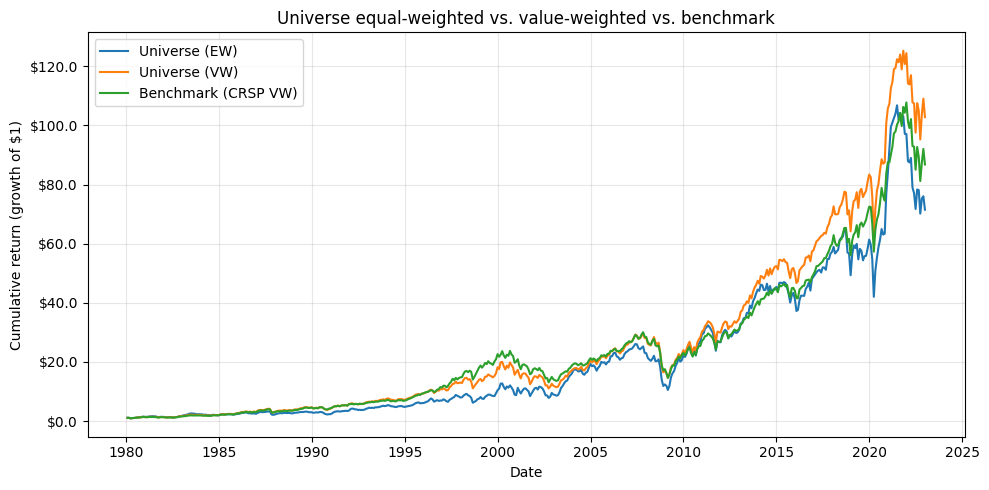

In [233]:
# --- Universe vs. benchmark: cumulative growth of $1 ---
# Universe = all stocks in our sample (ccm_port), EW and VW.
# Benchmark = CRSP value-weighted market (vw_ret).

def _universe_rets(g):
    ew = g['retadj'].mean()
    total_me = g['me_1'].sum()
    vw = (g['retadj'] * g['me_1']).sum() / total_me if total_me > 0 else np.nan
    return pd.Series({'universe_ew': ew, 'universe_vw': vw})

universe_by_date = ccm_port.groupby('jdate', group_keys=False).apply(_universe_rets).reindex(portfolio_rets.index)

# Align benchmark with universe dates
benchmark_ret = analysis_df.reindex(universe_by_date.index)['vw_ret']

# Cumulative growth of $1 (monthly returns)
cum = pd.DataFrame({
    'Universe (EW)': (1 + universe_by_date['universe_ew']).cumprod(),
    'Universe (VW)': (1 + universe_by_date['universe_vw']).cumprod(),
    'Benchmark (CRSP VW)': (1 + benchmark_ret).cumprod(),
}).dropna(how='all')

fig, ax = plt.subplots(figsize=(10, 5))
for col in cum.columns:
    ax.plot(cum.index, cum[col], label=col, lw=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative return (growth of $1)')
ax.set_title('Universe equal-weighted vs. value-weighted vs. benchmark')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.1f}'))
plt.tight_layout()
plt.show()

In [234]:
# --- Top 20 contributors to overall growth (equal-weighted universe) ---
# Each stock's cumulative return is computed over the full span it appears in the sample.
# Stocks can "cross over" between portfolios (e.g. P1 one year, P5 later); we track cumulative
# return at the stock level and summarize which portfolios they were in.

def stock_cumulative_and_portfolios(df):
    """For each permno: cumulative growth (1+ret).cumprod() over time, and months in each portfolio."""
    rows = []
    for permno, g in df.sort_values('jdate').groupby('permno'):
        ret = g['retadj']
        cum = (1 + ret).cumprod()
        final_growth = cum.iloc[-1]
        port_counts = g['portfolio'].value_counts().sort_index()
        port_str = ', '.join(f'P{p}:{c}' for p, c in port_counts.items())
        rows.append({
            'permno': permno,
            'cum_growth': final_growth,
            'cum_ret_pct': (final_growth - 1) * 100,
            'first_date': g['jdate'].min(),
            'last_date': g['jdate'].max(),
            'n_months': len(g),
            'portfolio_breakdown': port_str,
        })
    return pd.DataFrame(rows)

contrib = stock_cumulative_and_portfolios(ccm_port)
top20 = contrib.nlargest(20, 'cum_growth').reset_index(drop=True)
top20.insert(0, 'rank', range(1, len(top20) + 1))

# Fetch company names from CRSP (msenames has namedt/nameendt; company name may be comnam or in stocknames)
permnos = top20['permno'].unique().tolist()
name_col = None
try:
    names_sql = f"SELECT permno, comnam, namedt, nameendt FROM crsp.msenames WHERE permno IN ({','.join(map(str, permnos))})"
    names_raw = db.raw_sql(names_sql)
    names_raw['namedt'] = pd.to_datetime(names_raw['namedt'])
    names_raw['nameendt'] = pd.to_datetime(names_raw['nameendt'], errors='coerce')  # NULL -> NaT (still active)
    if 'comnam' in names_raw.columns:
        name_col = 'comnam'
    elif 'ncomnam' in names_raw.columns:
        name_col = 'ncomnam'
except Exception as e:
    names_raw = pd.DataFrame()
    print(f"Name lookup note: {e}")
if name_col and len(names_raw) > 0:
    last_dates = top20.set_index('permno')['last_date']
    names_by_permno = {}
    for p in permnos:
        sub = names_raw[names_raw['permno'] == p]
        if len(sub) == 0:
            names_by_permno[p] = f"permno {p}"
            continue
        ld = last_dates.get(p, sub['namedt'].max())
        # Name valid at last_date: namedt <= ld and (nameendt is null or nameendt >= ld)
        valid = sub[(sub['namedt'] <= ld) & (sub['nameendt'].isna() | (sub['nameendt'] >= ld))]
        if len(valid) > 0:
            names_by_permno[p] = valid.iloc[0][name_col]
        else:
            # Take most recent by nameendt (or by namedt if all nameendt are NaT)
            if sub['nameendt'].notna().any():
                names_by_permno[p] = sub.loc[sub['nameendt'].idxmax(), name_col]
            else:
                names_by_permno[p] = sub.loc[sub['namedt'].idxmax(), name_col]
    top20['Company'] = top20['permno'].map(names_by_permno)
else:
    top20['Company'] = top20['permno'].astype(str).str.replace(r'^', 'permno ', regex=True)

display_cols = ['rank', 'Company', 'cum_growth', 'cum_ret_pct', 'first_date', 'last_date', 'n_months', 'portfolio_breakdown']
top20_display = top20[display_cols].copy()
top20_display['cum_growth'] = top20_display['cum_growth'].round(2)
top20_display['cum_ret_pct'] = top20_display['cum_ret_pct'].round(1)
top20_display = top20_display.rename(columns={
    'cum_growth': 'Cum growth ($ per $1)',
    'cum_ret_pct': 'Cum return (%)',
    'first_date': 'First date',
    'last_date': 'Last date',
    'n_months': 'Months in universe',
    'portfolio_breakdown': 'Portfolios (P#: months)',
})

print('Top 20 contributors by cumulative return (equal-weighted universe; stocks can move across portfolios):')
display(top20_display)

Top 20 contributors by cumulative return (equal-weighted universe; stocks can move across portfolios):


,rank,Company,Cum growth ($ per $1),Cum return (%),First date,Last date,Months in universe,Portfolios (P#: months)
0,1,KANSAS CITY SOUTHERN,6543.17,654217.0,1980-01-31,2021-11-30,503,P0:503
1,2,MAXIM INTEGRATED PRODUCTS INC,1793.18,179218.3,1988-07-31,2021-07-31,328,"P1:24, P2:96, P3:109, P4:87, P5:12"
2,3,HENRY JACK & ASSOC INC,1530.47,152946.8,1986-07-31,2022-12-31,438,"P1:234, P2:168, P3:36"
3,4,SHERWIN WILLIAMS CO,1518.40,151740.0,1980-01-31,2020-06-30,486,"P1:348, P2:84, P3:12, P4:24, P5:18"
4,5,PAYCHEX INC,1431.83,143082.5,1984-07-31,2022-12-31,462,P0:462
5,6,KROGER CO,1364.23,136323.1,1980-01-31,2022-12-31,456,P0:456
6,7,GRACO INC,1290.80,128980.2,1980-01-31,2022-12-31,516,"P1:102, P2:168, P3:36, P4:132, P5:78"
7,8,HASBRO INC,1281.89,128088.7,1980-01-31,2022-12-31,516,"P2:36, P3:318, P4:120, P5:42"
8,9,GENTEX CORP,1268.06,126706.2,1982-07-31,2022-12-31,486,"P1:120, P2:270, P3:96"
9,10,APPLIED MATERIALS INC,1266.13,126513.1,1980-01-31,2020-06-30,330,"P3:36, P4:192, P5:102"


In [235]:
# Display results: one table per period with column groups Shared | CAPM | FF3F and row groups EW / VW
for period_name, results_df in all_results.items():
    caption_suffix = f"<br><b>{period_name}</b>"
    combined = build_combined_capm_ff3_table(results_df)
    if not combined.empty:
        display(HTML(create_combined_table_html(combined, custom_css, caption_suffix=caption_suffix, column_groups=True)))

In [236]:
# Report the average and recent number of firms in each portfolio.
# This confirms that portfolios are populated consistently over time.
n_firms = port_rets.pivot(index='jdate', columns='portfolio', values='n_firms')
n_firms.columns = [f'P{int(c)}' for c in n_firms.columns]

print("Average number of firms per portfolio:")
print(n_firms.mean().round(0))
print()
print("Number of firms per portfolio over time (sample):")
n_firms.tail(10)

Average number of firms per portfolio:
P0    1846.0
P1     305.0
P2     304.0
P3     303.0
P4     301.0
P5     297.0
dtype: float64

Number of firms per portfolio over time (sample):


,P0,P1,P2,P3,P4,P5
jdate,,,,,,
2022-03-31,1380,279,277,263,270,268
2022-04-30,1373,278,276,262,270,266
2022-05-31,1366,278,274,261,267,265
2022-06-30,1360,277,272,260,267,264
2022-07-31,1630,308,302,304,306,307
2022-08-31,1624,307,301,303,303,304
2022-09-30,1618,305,301,301,303,303
2022-10-31,1604,305,299,298,301,300
2022-11-30,1591,305,299,296,300,298


---
## Step 9: Visualizations — Cumulative Returns

The charts below show the growth of $1 invested in each portfolio over the analysis period.  

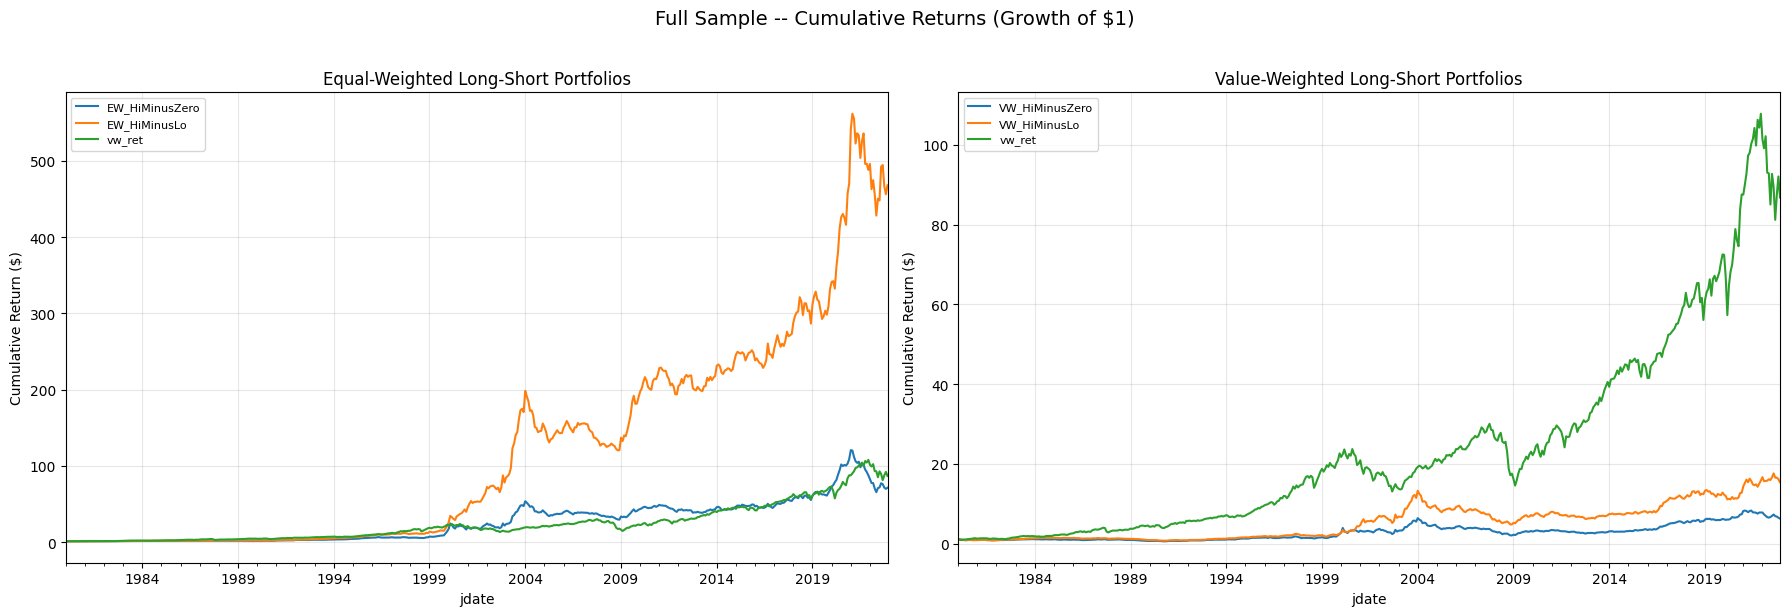

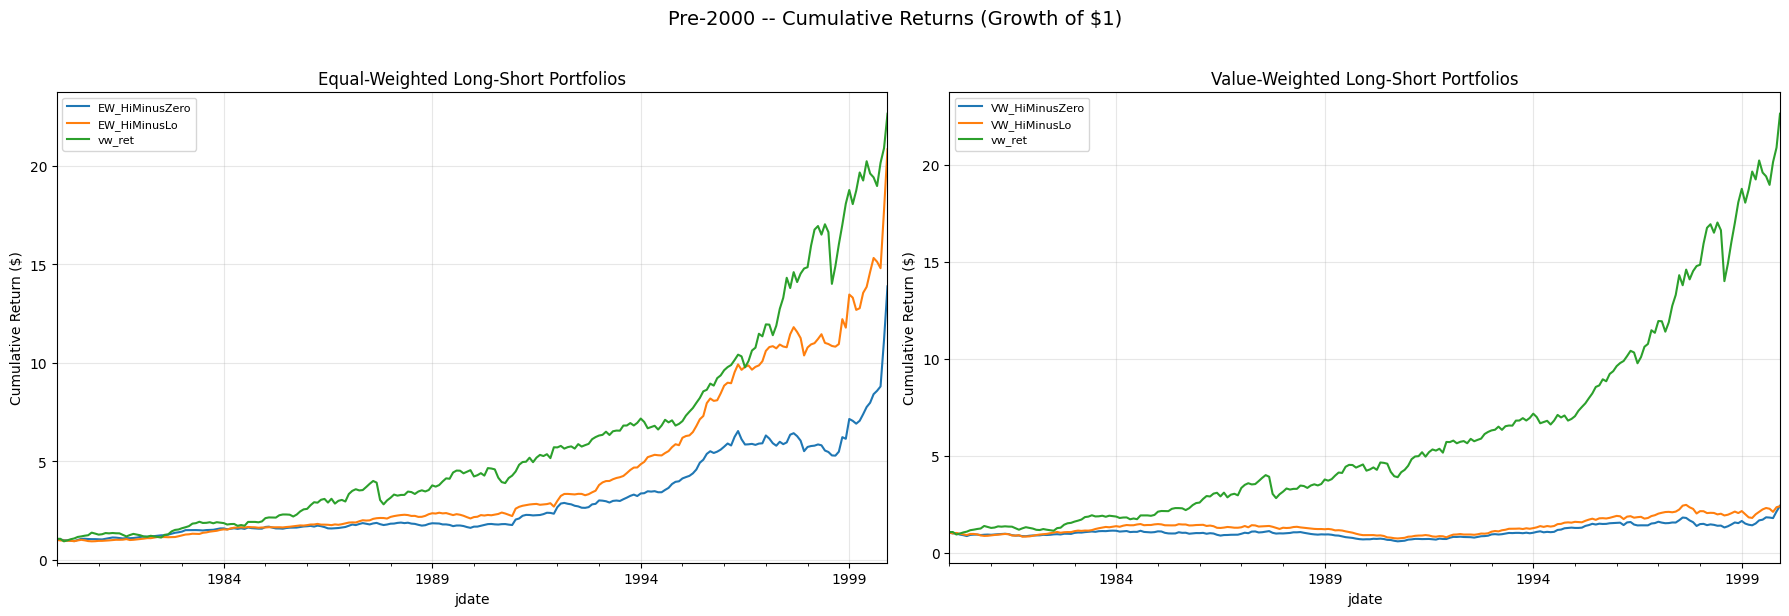

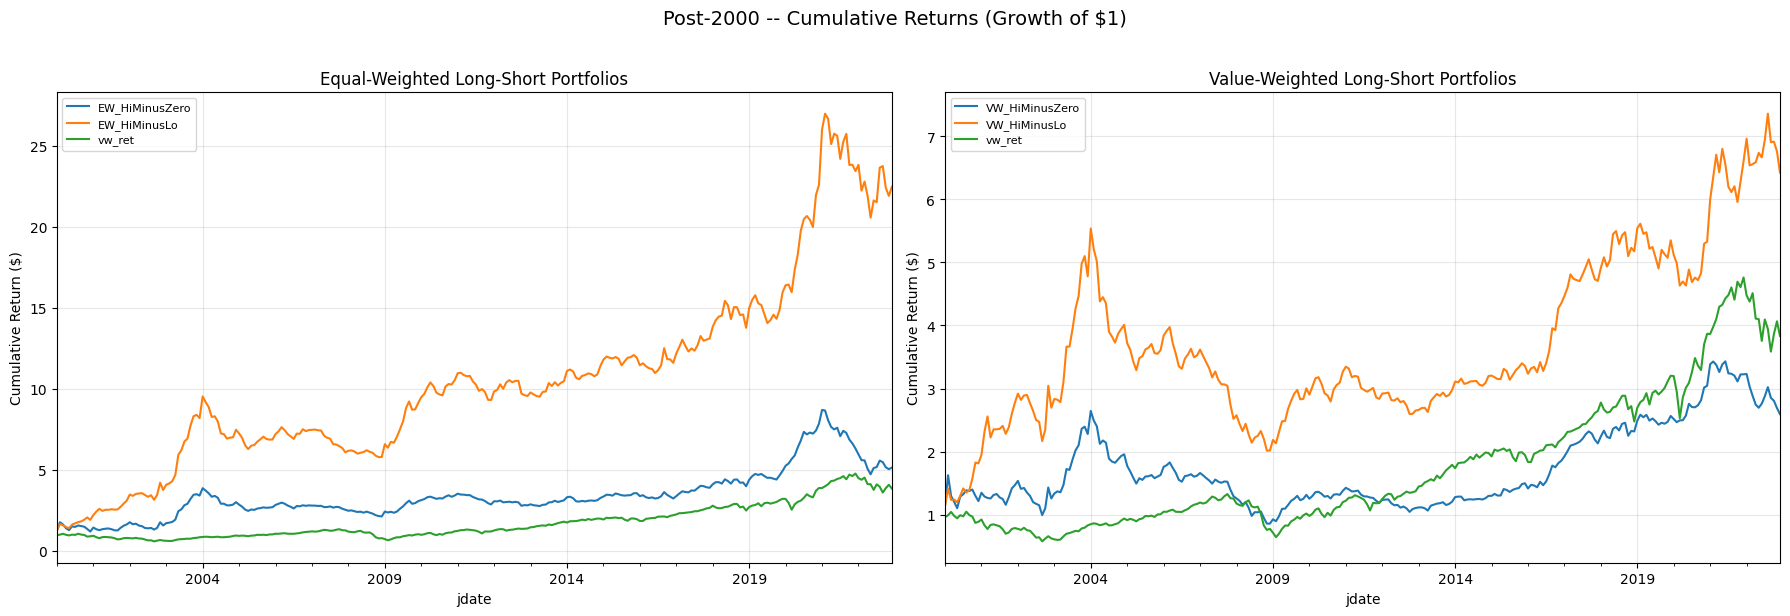

In [ ]:
# Plot cumulative growth of $1 for the long-short spread portfolios only.
# These charts show whether the R&D premium persisted or reversed over time.
base_port_cols = ['EW_HiMinusZero', 'EW_HiMinusLo',
                  'VW_HiMinusZero', 'VW_HiMinusLo', 'vw_ret']

for period_name, (start, end_dt) in periods.items():
    sub_df = analysis_df[(analysis_df.index >= start) & (analysis_df.index <= end_dt)]

    if len(sub_df) < 12:
        continue

    cum_rets = (1 + sub_df[base_port_cols]).cumprod()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{period_name} -- Cumulative Returns (Growth of $1)', fontsize=14, y=1.02)

    ew_plot_cols = [c for c in base_port_cols if c.startswith('EW_')]
    ew_plot_cols.append('vw_ret')
    cum_rets[ew_plot_cols].plot(ax=axes[0], title='Equal-Weighted Long-Short Portfolios')
    axes[0].set_ylabel('Cumulative Return ($)')
    axes[0].legend(loc='upper left', fontsize=8)
    axes[0].grid(True, alpha=0.3)

    vw_plot_cols = [c for c in base_port_cols if c.startswith('VW_')]
    vw_plot_cols.append('vw_ret')
    cum_rets[vw_plot_cols].plot(ax=axes[1], title='Value-Weighted Long-Short Portfolios')
    axes[1].set_ylabel('Cumulative Return ($)')
    axes[1].legend(loc='upper left', fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Close the WRDS database connection once all data has been loaded and analyzed
db.close()

In [ ]:
analysis_df.to_clipboard()